In [1]:
#%%
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import os
period='rcp85'
variable='t'
domain = 'd03'
if variable == "t":
    var = 'T2'
    filename = 't_'+domain+'_daily_newdim'
elif variable == "pr":
    var = 'pr'
    filename = 'pr_'+domain+'_daily'
elif variable == "wind":
    var = 'wspd'
    if domain=="d03":
        filename =  'wind_d03_daily_wspd'#'wspd_'+domain+'_mon'
    else:
        filename = "wind_"+domain+'_daily'
    
geo_em_file = '/gpfs/fs7/dfo/hpcmc/pfm/spfm000/CanESM2-WRF/domain/geo_em.'+domain+'.nc'  #'/Users/evagnegy/Desktop/CanESM2_WRF_Eval/domain/geo_em.'+domain+'.nc'
basepath='/gpfs/fs7/dfo/hpcmc/pfm/spfm000/CanESM2-WRF/'
#gridded_data_path = '/Users/evagnegy/Desktop/CanESM2_WRF_Eval/gridded_model_data/daily/'


# === Load land mask ===
landmask = xr.open_dataset(geo_em_file)['LANDMASK'].squeeze()
landmask = landmask.rename({'south_north': 'lat', 'west_east': 'lon'})  # ensure standard naming
if 'south_north' in landmask.coords:
    landmask = landmask.rename({'south_north': 'lat'})
if 'west_east' in landmask.coords:
    landmask = landmask.rename({'west_east': 'lon'})
print(landmask.dims)


('lat', 'lon')


In [2]:
import pickle

def getseasons(var, period, perc, rel, med):
    season_data = {}
    for s in seasons:
        filepath=f'/gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/Extremes/{var}_{s}_{period}_boots_1000_perc_{perc}{rel}{med}.pkl'
        #print('filepath', filepath)
        # ---- Load results ----
        with open(filepath, "rb") as f:
            data = pickle.load(f)
        perc_delta=data['perc_delta']
        p_val = data["p_value"]
        season_data[s] = (data[f"perc_delta"], data[f"p_value"])
    return season_data

In [3]:
#seasons = [ 'SON', 'JJA', 'MAM','DJF']
seasons = ["DJF", "MAM", "JJA", "SON"]
var='T2'; period='rcp45'; perc=95; rel=''; med=''
season_data_t = getseasons(var, period, perc, rel, med)
var='pr'; rel='_rel'
season_data_pr = getseasons(var, period, perc, rel, med)
var='wspd'; rel='_rel'
season_data_wind = getseasons(var, period, perc, rel, med)
var='T2';  perc=5; rel=''
season_data_tmin = getseasons(var, period, perc, rel, med)


In [4]:
def get_error(var, period, perc, rel, med):
    CI_data = {}
       
    for s in seasons:
        filepath = f'/gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/Extremes/{var}_{s}_{period}_region_null_boots_1000_perc_{perc}{rel}{med}.pkl'
        with open(filepath, "rb") as f:
            data = pickle.load(f)
        CI_data[s] = {
            'land_obs':    data['land_obs'],
            'ocean_obs':   data['ocean_obs'],
            'land_null_ci': data['land_null_ci'],
            'ocean_null_ci': data['ocean_null_ci'],
            'land_p_value': data['land_p_value'],
            'ocean_p_value': data['ocean_p_value']
        }
    
    return CI_data

In [5]:
var='pr';  perc=95; rel='_rel'
season_CI_tmin = get_error(var, period, perc, rel, med)


In [6]:
season_CI_tmin


{'DJF': {'land_obs': 6.99503923590152,
  'ocean_obs': 10.316221219032126,
  'land_null_ci': array([-3.58886459,  5.27668636]),
  'ocean_null_ci': array([-5.32171588,  6.43166014]),
  'land_p_value': 0.004,
  'ocean_p_value': 0.003},
 'MAM': {'land_obs': 1.9008860839461736,
  'ocean_obs': 5.91880928062915,
  'land_null_ci': array([-6.35477115,  9.21958791]),
  'ocean_null_ci': array([-5.7580678 ,  6.96400529]),
  'land_p_value': 0.599,
  'ocean_p_value': 0.071},
 'JJA': {'land_obs': 5.641338322610574,
  'ocean_obs': 7.651667135280789,
  'land_null_ci': array([-7.03825896, 12.84263467]),
  'ocean_null_ci': array([-7.43353394, 12.55215337]),
  'land_p_value': 0.277,
  'ocean_p_value': 0.136},
 'SON': {'land_obs': 13.464526627460863,
  'ocean_obs': 10.333221191600819,
  'land_null_ci': array([-7.20371836,  8.71380704]),
  'ocean_null_ci': array([-6.50142617,  7.61834489]),
  'land_p_value': 0.002,
  'ocean_p_value': 0.003}}

In [7]:
# Apply masks to data
landmask = landmask.values #.transpose('lon', 'lat')  # Now shape matches delta
land_mask = (landmask == 1)
ocean_mask = (landmask == 0)


In [8]:
def nanstandard_error(data):
    n = np.count_nonzero(~np.isnan(data))
    return np.nanstd(data, ddof=1) / np.sqrt(n)


In [9]:
def calculate_stats_by_mask(data, masks, seasons):
    """
    Calculate mean and standard error for multiple masks across seasons.
    
    Parameters:
    -----------
    data : dict
        Dictionary with season keys, where data[season][0] contains the numpy array
    masks : dict
        Dictionary of masks to apply, e.g., {'land': land_mask, 'ocean': ocean_mask}
    seasons : list
        List of season names
    
    Returns:
    --------
    dict
        Nested dictionary with structure: results[mask_name]['mean'] and results[mask_name]['stderr']
    """
    n_seasons = len(seasons)
    results = {
        mask_name: {
            'mean': np.zeros(n_seasons),
            'stderr': np.zeros(n_seasons)
        }
        for mask_name in masks.keys()
    }
    
    for kk, season in enumerate(seasons):
        X = data[season][0]
        
        for mask_name, mask in masks.items():
            masked_data = np.where(mask, X, np.nan)
            results[mask_name]['mean'][kk] = np.nanmean(masked_data)
            results[mask_name]['stderr'][kk] = nanstandard_error(masked_data)
    
    return results



In [10]:
def calculate_masked_stats(var, period, perc, rel, med, masks, seasons):
    """
    Complete pipeline: get data and calculate stats for all masks.
    
    Parameters:
    -----------
    var : str
        Variable name (e.g., 'T2', 'precip')
    period : str
        Period name (e.g., 'rcp45', 'rcp85')
    perc : int
        Percentile value (e.g., 5, 95)
    rel : str
        Relative parameter
    med : str
        Med parameter
    masks : dict
        Dictionary of masks to apply
    seasons : list
        List of season names
    
    Returns:
    --------
    dict
        Nested dictionary with structure: results[mask_name]['mean'] and results[mask_name]['stderr']
    """
    data = getseasons(var, period, perc, rel, med)
    return calculate_stats_by_mask(data, masks, seasons)



# When generating results, organize by variable:
all_results = {}

for var_name, var_code in [('T2', 'T2'), ('precip', 'PR'), ('wind', 'WIND')]:
    cases = {
        'rcp45_p95': {'var': var_code, 'period': 'rcp45', 'perc': 95},
        'rcp45_p5':  {'var': var_code, 'period': 'rcp45', 'perc': 5},
        'rcp85_p95': {'var': var_code, 'period': 'rcp85', 'perc': 95},
        'rcp85_p5':  {'var': var_code, 'period': 'rcp85', 'perc': 5},
    }
    
    all_results[var_name] = {}
    for case_name, params in cases.items():
        all_results[var_name][case_name] = calculate_masked_stats(
            var=params['var'],
            period=params['period'],
            perc=params['perc'],
            rel='',
            med='',
            masks={'land': land_mask, 'ocean': ocean_mask},
            seasons=seasons
        )

# Then access as: all_results['T2']['rcp45_p95']['ocean']['mean']

In [11]:
# Define all your cases upfront
cases = {
    'rcp45_p95': {'var': 'T2', 'period': 'rcp45', 'perc': 95},
    'rcp45_p5':  {'var': 'T2', 'period': 'rcp45', 'perc': 5},
    'rcp85_p95': {'var': 'T2', 'period': 'rcp85', 'perc': 95},
    'rcp85_p5':  {'var': 'T2', 'period': 'rcp85', 'perc': 5},
}

masks = {'land': land_mask, 'ocean': ocean_mask}
results = {}

for case_name, params in cases.items():
    results[case_name] = calculate_masked_stats(
        var=params['var'],
        period=params['period'],
        perc=params['perc'],
        rel='',
        med='',
        masks=masks,
        seasons=seasons
    )

# Easy access with meaningful names:
ocean_del_rcp45_p95 = results['rcp45_p95']['ocean']['mean']
ocean_err_rcp45_p95 = results['rcp45_p95']['ocean']['stderr']
ocean_del_rcp45_p5  = results['rcp45_p5']['ocean']['mean']
print(ocean_del_rcp45_p95, 3.*ocean_err_rcp45_p95)

[1.80922309 1.59109214 1.63867915 1.94382677] [0.00217162 0.00209846 0.00469976 0.00501978]


[Text(1, 0, ''), Text(2, 0, ''), Text(3, 0, ''), Text(4, 0, '')]

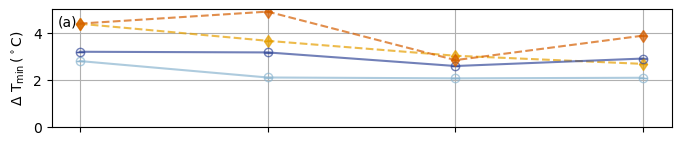

In [12]:
# Ocean colors
color3 = '#364B9A'  # Ocean (RCP8.5) — deep blue
color2 = '#8CB6D0'  # Ocean (RCP4.5) — light muted blue

# Land colors
color4 = '#D55E00'  # Land (RCP8.5) — warm reddish-orange
color1 = '#E69F00'  # Land (RCP4.5) — golden yellow

subpanel = ['(a)','(b)','(c)','(d)', '(e)', '(f)', 'g','h','i','j']

at = 0.01
bt = .95

months = np.arange(1, 5)
plt.figure(figsize=(8,7))

# Common errorbar parameters
errorbar_params = {
    'capsize': 3,
    'capthick': 1,
    'elinewidth': 1,
    'alpha': 0.7
}

# ==================== Panel 1: Tmin (5th percentile) ====================
ax = plt.subplot(4, 1, 1)

plt.errorbar(months, results['rcp45_p5']['ocean']['mean'], 
             yerr=3.*results['rcp45_p5']['ocean']['stderr'], 
             label='Ocean RCP 4.5', marker='o', color=color2, 
             markerfacecolor='none', **errorbar_params)
plt.errorbar(months, results['rcp45_p5']['land']['mean'], 
             yerr=results['rcp45_p5']['land']['stderr'],
             label='Land RCP 4.5', linestyle='--', marker='d', 
             color=color1, markeredgecolor=color1, **errorbar_params)

plt.errorbar(months, results['rcp85_p5']['ocean']['mean'], 
             yerr=3.*results['rcp85_p5']['ocean']['stderr'],
             label='Ocean RCP 8.5', marker='o', color=color3, 
             markerfacecolor='none', **errorbar_params)
plt.errorbar(months, results['rcp85_p5']['land']['mean'], 
             yerr=3.*results['rcp85_p5']['land']['stderr'],
             label='Land RCP 8.5', linestyle='--', marker='d', 
             color=color4, markeredgecolor=color4, **errorbar_params)

ax.text(at, bt, subpanel[0], transform=ax.transAxes, va='top', 
        fontweight='normal', zorder=1000)
plt.ylabel(r'$\Delta \ \mathrm{T}_{\mathrm{min}}\, (^\circ \mathrm{C})$')
plt.grid(True)
plt.xticks(months)
plt.axis('tight')
plt.ylim([0,5])
ax.set_xticklabels([])

NameError: name 'ocean_del_min' is not defined

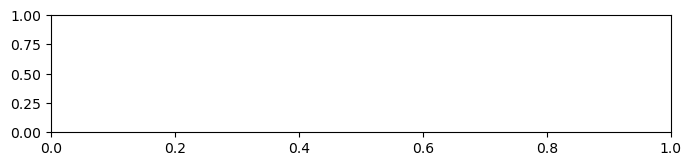

In [13]:
# Ocean colors
color3 = '#364B9A'  # Ocean (historical) — deep blue
color2 = '#8CB6D0'  # Ocean (RCP8.5) — light muted blue

# Land colors
color4 = '#D55E00'  # Land (historical) — warm reddish-orange
color1 = '#E69F00'  # Land (RCP8.5) — golden yellow

subpanel = ['(a)','(b)','(c)','(d)', '(e)', '(f)', 'g','h','i','j']

at = 0.01
bt = .95

months = np.arange(1, 5)
plt.figure(figsize=(8,7))

# Common errorbar parameters
errorbar_params = {
    'capsize': 3,
    'capthick': 1,
    'elinewidth': 1,
    'alpha': 0.7
}

# ==================== Panel 1: Tmin ====================
ax = plt.subplot(4, 1, 1)

plt.errorbar(months, ocean_del_min, yerr=ocean_err_min, 
             label='Ocean RCP 4.5', marker='o', color=color2, 
             markerfacecolor='none', **errorbar_params)
plt.errorbar(months, land_del_min, yerr=land_err_min,
             label='Land RCP 4.5', linestyle='--', marker='d', 
             color=color1, markeredgecolor=color1, **errorbar_params)

plt.errorbar(months, ocean_del_min85, yerr=ocean_err_min85,
             label='Ocean RCP 8.5', marker='o', color=color3, 
             markerfacecolor='none', **errorbar_params)
plt.errorbar(months, land_del_min85, yerr=land_err_min85,
             label='Land RCP 8.5', linestyle='--', marker='d', 
             color=color4, markeredgecolor=color4, **errorbar_params)

ax.text(at, bt, subpanel[0], transform=ax.transAxes, va='top', 
        fontweight='normal', zorder=1000)
plt.ylabel(r'$\Delta \ \mathrm{T}_{\mathrm{min}}\, (^\circ \mathrm{C})$')
plt.grid(True)
plt.xticks(months)
plt.axis('tight')
plt.ylim([0,5])
ax.set_xticklabels([])

In [14]:

land_del=np.zeros(4);land_err=np.zeros(4)
ocean_del=np.zeros(4); ocean_err=np.zeros(4)
var='T2'; period='rcp45'; perc=95; rel=''; med=''
data=getseasons(var, period, perc, rel, med)

kk = 0
for season in seasons:
    X = data[season][0]   # numpy.ndarray

    del_mo_l  = np.where(land_mask,  X, np.nan)
    del_mo_oc = np.where(ocean_mask, X, np.nan)

    land_del[kk]  = np.nanmean(del_mo_l)
    ocean_del[kk] = np.nanmean(del_mo_oc)
    ocean_err[kk]=nanstandard_error(del_mo_oc)
    land_err[kk]=nanstandard_error(del_mo_l)

    kk += 1

print(ocean_del)
print(land_del)

[1.80922309 1.59109214 1.63867915 1.94382677]
[1.56916524 0.83044695 3.24564613 2.68933744]


In [15]:
land_del85=np.zeros(4)
ocean_del85=np.zeros(4)
var='T2'; period='rcp85'; perc=95; rel=''; med=''
data=getseasons(var, period, perc, rel, med)

kk = 0
for season in seasons:
    X = data[season][0]   # numpy.ndarray

    del_mo_l  = np.where(land_mask,  X, np.nan)
    del_mo_oc = np.where(ocean_mask, X, np.nan)

    land_del85[kk]  = np.nanmean(del_mo_l)
    ocean_del85[kk] = np.nanmean(del_mo_oc)

    kk += 1

print(ocean_del85)
print(land_del85)

[2.30773972 2.28055625 2.42315936 3.00555757]
[2.02979729 1.16011709 3.63253373 2.8831266 ]


In [16]:
land_del_min=np.zeros(4)
ocean_del_min=np.zeros(4)
var='T2'; period='rcp45'; perc=5; rel=''; med=''
data=getseasons(var, period, perc, rel, med)

kk = 0
for season in seasons:
    X = data[season][0]   # numpy.ndarray

    del_mo_l  = np.where(land_mask,  X, np.nan)
    del_mo_oc = np.where(ocean_mask, X, np.nan)

    land_del_min[kk]  = np.nanmean(del_mo_l)
    ocean_del_min[kk] = np.nanmean(del_mo_oc)

    kk += 1

print(seasons, ocean_del_min)
print(land_del)

['DJF', 'MAM', 'JJA', 'SON'] [2.79235001 2.09118069 2.05510979 2.07966252]
[1.56916524 0.83044695 3.24564613 2.68933744]


In [17]:
land_del_min85=np.zeros(4)
ocean_del_min85=np.zeros(4)
var='T2'; period='rcp85'; perc=5; rel=''; med=''
data=getseasons(var, period, perc, rel, med)

kk = 0
for season in seasons:
    X = data[season][0]   # numpy.ndarray

    del_mo_l  = np.where(land_mask,  X, np.nan)
    del_mo_oc = np.where(ocean_mask, X, np.nan)

    land_del_min85[kk]  = np.nanmean(del_mo_l)
    ocean_del_min85[kk] = np.nanmean(del_mo_oc)

    kk += 1

print(seasons, ocean_del_min85)
print(land_del_min85)

['DJF', 'MAM', 'JJA', 'SON'] [3.18925627 3.16091253 2.58101485 2.90002389]
[4.39127156 4.90255217 2.83289777 3.87941688]


In [18]:
land_del_pr85=np.zeros(4)
ocean_del_pr85=np.zeros(4)
var='pr'; period='rcp85'; perc=95; rel='_rel'; med=''
data=getseasons(var, period, perc, rel, med)

kk = 0
for season in seasons:
    X = data[season][0]   # numpy.ndarray

    del_mo_l  = np.where(land_mask,  X, np.nan)
    del_mo_oc = np.where(ocean_mask, X, np.nan)

    land_del_pr85[kk]  = np.nanmean(del_mo_l)
    ocean_del_pr85[kk] = np.nanmean(del_mo_oc)

    kk += 1

print(seasons, ocean_del_pr85)
print(land_del_pr85)

['DJF', 'MAM', 'JJA', 'SON'] [ 17.74386128  12.81312244 -19.87761274  19.72707306]
[ 16.79798896  17.7123605  -25.40883227  29.34339898]


In [19]:
land_del_pr=np.zeros(4)
ocean_del_pr=np.zeros(4)
var='pr'; period='rcp45'; perc=95; rel='_rel'; med=''
data=getseasons(var, period, perc, rel, med)

kk = 0
for season in seasons:
    X = data[season][0]   # numpy.ndarray

    del_mo_l  = np.where(land_mask,  X, np.nan)
    del_mo_oc = np.where(ocean_mask, X, np.nan)

    land_del_pr[kk]  = np.nanmean(del_mo_l)
    ocean_del_pr[kk] = np.nanmean(del_mo_oc)

    kk += 1

print(seasons, ocean_del_pr)
print(land_del_pr)

['DJF', 'MAM', 'JJA', 'SON'] [ 17.08838389   0.89739292 -17.27420851  10.58024006]
[ 17.92963362  -0.71370045 -23.09561246  21.16754916]


In [20]:
land_del_wind85=np.zeros(4)
ocean_del_wind85=np.zeros(4)
var='wspd'; period='rcp85'; perc=95; rel='_rel'; med=''
data=getseasons(var, period, perc, rel, med)

kk = 0
for season in seasons:
    X = data[season][0]   # numpy.ndarray

    del_mo_l  = np.where(land_mask,  X, np.nan)
    del_mo_oc = np.where(ocean_mask, X, np.nan)

    land_del_wind85[kk]  = np.nanmean(del_mo_l)
    land_del_wind85[kk]  = np.nanmean(del_mo_l)
    ocean_del_wind85[kk] = np.nanmean(del_mo_oc)

    kk += 1

print(seasons, ocean_del_wind85)
print(land_del_wind85)

['DJF', 'MAM', 'JJA', 'SON'] [ 1.59897718 -1.39965787 -0.53066797  1.23677103]
[-1.56861598 -3.96622543 -5.23085912  0.72045146]


In [21]:
land_del_wind=np.zeros(4)
ocean_del_wind=np.zeros(4)
var='wspd'; period='rcp45'; perc=95; rel='_rel'; med=''
data=getseasons(var, period, perc, rel, med)

kk = 0
for season in seasons:
    X = data[season][0]   # numpy.ndarray

    del_mo_l  = np.where(land_mask,  X, np.nan)
    del_mo_oc = np.where(ocean_mask, X, np.nan)

    land_del_wind[kk]  = np.nanmean(del_mo_l)
    ocean_del_wind[kk] = np.nanmean(del_mo_oc)

    kk += 1

print(seasons, ocean_del_wind)
print(land_del_wind)

['DJF', 'MAM', 'JJA', 'SON'] [ 3.83990314 -3.20237941  0.28721439 -0.75084596]
[-0.31075209 -5.03062276 -4.39589863  0.71577401]


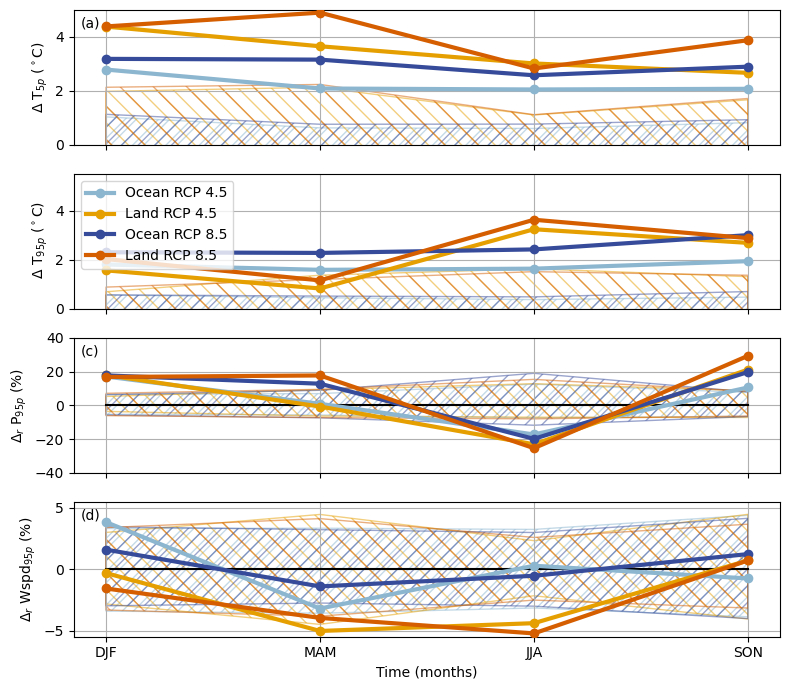

In [89]:
# Ocean colors
color3 = '#364B9A'  # Ocean (historical) — deep blue
color2 = '#8CB6D0'  # Ocean (RCP8.5) — light muted blue

# Land colors
color4 = '#D55E00'  # Land (historical) — warm reddish-orange
color1 = '#E69F00'  # Land (RCP8.5) — golden yellow

subpanel = ['(a)','(b)','(c)','(d)', '(e)', '(f)', 'g','h','i','j']
#subpanel = ['1','2','3', '4', '5','6']

at=0.01
bt=.95
mycolors= {'ocean_rcp45':color2, 'ocean_rcp85':color3, 'land_rcp45':color1, 'land_rcp85':color4}
myhatch= {'ocean_rcp45':'///', 'ocean_rcp85':'//', 'land_rcp45':'\\\\', 'land_rcp85':'\\'}
labels={"t": r" $\Delta$ T$_{95p}$ ($^\circ$C) ", "tmin":r"$\Delta$ T$_{5p}$ ($^\circ$C)", "pr": '$\Delta_r$ P$_{95p}$ (%)', "wind": '$\Delta_r$ Wspd$_{95p}$ (%)'}
name0={"t": "T2", "tmin":"T2", "wind": "wspd", "pr":"pr"}
fill = True
months = np.arange(1, 5)
plt.figure(figsize=(8,7))
ax = plt.subplot(4, 1, 1)
#om, lm=getaverages('t', period, domain)
#def plot_means(ocean, land, ocean_85, land_85):
 #   plt.plot(months, ocean, '--',label='ocean', marker='o', color=mycolors['ocean_45'], markerfacecolor='none')
  #  plt.plot(months, land, '--',label='land',  marker='d', color=mycolors['land_45'],  markeredgecolor=mycolors['land_45'])
    
   # plt.plot(months, ocean_85,'--', label='ocean RCP 8.5', marker='o', color=mycolors['ocean_85'], markerfacecolor='none')
    #plt.plot(months, land_85,'--', label='land RCP 8.5',  marker='d', color=mycolors['land_85'],  markeredgecolor=mycolors['land_85'])
    #return
def plot_means(ocean, land, ocean_85, land_85):
    # RCP 4.5 (thin)
    period='rcp45'
    plt.plot(months, ocean,'-o',
             color=mycolors['ocean_'+period],
             lw=3,
             label='Ocean RCP 4.5',
             zorder=3)
    
    plt.plot(months, land,'-o',
             color=mycolors['land_'+period],
             lw=3,
             label='Land RCP 4.5',
             zorder=3)

    # RCP 8.5 (thick)
    period='rcp85'
    plt.plot(months, ocean_85,'-o',
             color=mycolors['ocean_'+period],
             lw=3.0,
             label='Ocean RCP 8.5',
             zorder=4)

    plt.plot(months, land_85,'-o',
             color=mycolors['land_'+period],
             lw=3.0,
             label='Land RCP 8.5',
             zorder=4)
def plot_myci(domain, ci, color_key, fill):
    ci_low  = [ci[s][domain + '_null_ci'][0] for s in seasons]
    ci_high = [ci[s][domain + '_null_ci'][1] for s in seasons]
    if fill:
        offset = 0.05 if 'rcp85' in color_key else 0.0
        ax.fill_between(months, np.array(ci_low)+offset, np.array(ci_high),
                       hatch=myhatch[color_key],facecolor='none', 
                    alpha=0.5, edgecolor=mycolors[color_key]) #need dict of rcp for colors
    else:
        ax.plot(months,
            ci_high,
            color=mycolors[color_key],
            alpha=0.8,
            linestyle='--',
            linewidth=1,
            zorder=5
        )
        ax.plot(months,
            ci_low,
            color=mycolors[color_key],
            alpha=0.8,
            linestyle='--',
            linewidth=1,
            zorder=5
        )

#def plot_myci(domain, fill, ci):
 #   ocean_obs     = [ci[s][domain+'_obs'] for s in seasons]
  #  ocean_ci_low  = [ci[s][domain+'_null_ci'][0] for s in seasons]
   # ocean_ci_high = [ci[s][domain+'_null_ci'][1] for s in seasons]
    #if fill:
     #   plt.plot(months,  ocean_ci_high, '-', color=mycolors[domain+'_45'], linewidth=0.75)
      #  plt.plot(months,  ocean_ci_low, '-', color=mycolors[domain+'_45'], linewidth=0.75)
       # ax.fill_between(months, ocean_ci_low, ocean_ci_high,
     #               alpha=0.1, color=mycolors[domain+'_45']) #need dict of rcp for colors
    #else:
     #   plt.plot(months,  ocean_ci_high, '-', color=mycolors[domain+'_45'], linewidth=0.7)
    #return

def plotErrors(var, period, perc, rel, med, fill ):
    ci = get_error(name0[var], period, perc, rel, med)
    #print(period)
    plot_myci('ocean',  ci, 'ocean_'+period,fill)
    plot_myci('land',  ci,'land_'+period,fill)
         
    return

plot_means(ocean_del_min, land_del_min, ocean_del_min85, land_del_min85)

#%%%%%%%%%%%%%%%%%%%5 Add the CI from the significance tests
plotErrors('tmin', 'rcp45', 5, '', '', fill)
plotErrors('tmin', 'rcp85', 5, '', '', fill)

#%%%%%%%%%%%%%%%%

ax.text(at, bt, subpanel[0], transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000)
plt.ylabel(labels["tmin"])
plt.grid(True)
plt.xticks(months)
plt.axis('tight')
plt.ylim([0,5])
ax.set_xticklabels([])

########################
ax = plt.subplot(4, 1, 2)
#om, lm=getaverages('t', period, domain)
plot_means(ocean_del, land_del, ocean_del85, land_del85)
#%%%%%%%%%%%%%%%%%%%5 Add the CI from the significance tests
plotErrors('t', 'rcp45', 95, '', '', fill)
plotErrors('t', 'rcp85', 95, '', '', fill)

#%%%%%%%%%%%%%%%%

plt.ylabel(labels["t"])
plt.grid(True)
plt.xticks(months)
plt.axis('tight')
plt.ylim([0,5.5])
ax.set_xticklabels([])
plt.legend(loc='upper left')


ax = plt.subplot(4, 1, 4)
plot_means(ocean_del_wind, land_del_wind, ocean_del_wind85, land_del_wind85)
#%%%%%%%%%%%%%%%%%%%5 Add the CI from the significance tests
plotErrors('wind', 'rcp45', 95, '_rel', '', fill)
plotErrors('wind', 'rcp85', 95, '_rel', '', fill)

plt.plot(months, np.zeros(4), '-k')
ax.text(at, bt, subpanel[3], transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000)
plt.ylim([-5.5,5.5])
plt.grid(True)
plt.xticks(months)
ax.set_xticklabels(seasons)

plt.ylabel(labels["wind"])
plt.xlabel('Time (months)')
#plt.axis('tight')
#plt.ylabel(f'Monthly Mean Δ ({period} vs hist)')
ax = plt.subplot(4, 1, 3)
plot_means(ocean_del_pr, land_del_pr, ocean_del_pr85, land_del_pr85)
#%%%%%%%%%%%%%%%%%%%5 Add the CI from the significance tests
plotErrors('pr', 'rcp45', 95, '_rel', '', fill)
plotErrors('pr', 'rcp85', 95, '_rel', '', fill)

plt.plot(months, np.zeros(4), '-k')

plt.ylabel(labels["pr"])
ax.set_xticklabels([])

#plt.ylabel(f'Mean fractional change in {var}')
#plt.ylabel(f'Monthly Mean Δ ({period} vs hist)')
plt.xticks(months)
ax.text(at, bt, subpanel[2], transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000)
plt.ylim([-40,40])
plt.grid(True)
#plt.axis('tight')
plt.tight_layout()
plt.savefig('Regional_averages_relative_extremes_hatch.png', format='png', bbox_inches='tight',transparent=False,dpi=500)


## 